In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df_train = pd.read_csv('Marathon_dataset/train.csv')

In [42]:
df_train.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [43]:
df_train.shape

(80000, 41)

In [44]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

In [45]:
df_train.describe()

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,...,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
count,80000.000000,80000.000000,80000.000000,80000.000000,69255.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,78011.000000,80000.000000,80000.000000
mean,41.538412,36.147413,2.004700,5.505575,259.321580,29.940183,17.225917,4.356975,15.828567,0.978862,...,34.382600,29.235175,64.490900,40.010475,60.272625,52.179725,249.308687,287.931407,6.372187,0.450000
std,13.848164,35.453932,1.419094,2.871288,33.778153,17.392518,7.072490,0.896649,2.358518,0.645074,...,24.113435,21.936089,17.171607,28.388266,20.957232,24.647479,30.372115,33.648005,2.067061,0.804679
min,18.000000,6.000000,0.000000,1.000000,132.000000,20.000000,12.400000,3.000000,15.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,171.000000,1.000000,0.000000
25%,30.000000,10.000000,1.000000,3.000000,236.000000,20.000000,12.400000,4.000000,15.000000,1.000000,...,15.000000,11.000000,53.000000,16.000000,46.000000,35.000000,228.000000,265.000000,5.000000,0.000000
50%,42.000000,25.000000,2.000000,6.000000,261.000000,20.600000,12.400000,4.000000,15.000000,1.000000,...,33.000000,28.000000,65.000000,39.000000,61.000000,52.000000,252.000000,290.000000,7.000000,0.000000
75%,54.000000,49.000000,3.000000,8.000000,283.000000,34.300000,20.500000,5.000000,15.000000,1.000000,...,51.000000,45.000000,77.000000,61.000000,75.000000,70.000000,272.000000,313.000000,8.000000,1.000000
max,65.000000,240.000000,11.000000,10.000000,377.000000,119.994348,60.200000,7.000000,41.200000,3.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,350.000000,400.000000,10.000000,3.000000


In [46]:
missing = df_train.isnull().sum()
print(missing[missing > 0])

personal_best_minutes            10745
cross_training_hours_per_week     7983
vo2_max                           9611
sleep_hours_avg                   3942
injury_severity                  47350
nutrition_score                   6402
hydration_consistency             6402
actual_finish_time_minutes        1989
dtype: int64


In [47]:
df_train

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,R052366,26,Female,101,0,Advanced,1,NaN,20.0,12.4,...,0,53,39,2024-05-01,Hot,Mixed,210,251.0,6,0
79996,R006856,47,Female,6,2,Beginner,1,302.0,20.0,12.4,...,0,40,14,2024-05-26,Rainy,Hilly,265,318.0,5,0
79997,R002961,63,Female,72,1,Advanced,8,225.0,44.5,27.7,...,50,65,76,2025-05-22,Hot,Mixed,236,274.0,5,0
79998,R093611,19,Male,13,3,Beginner,10,264.0,42.6,26.5,...,100,41,39,2024-04-08,Cloudy,Flat,256,279.0,7,2


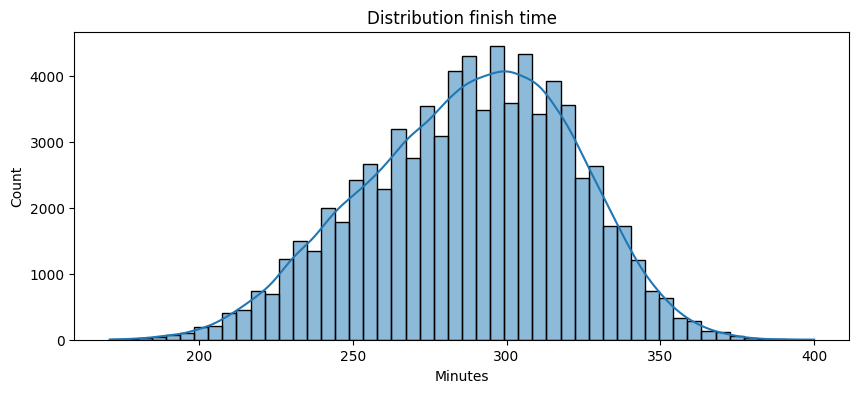

In [48]:
plt.figure(figsize=(10, 4))
sns.histplot(df_train['actual_finish_time_minutes'].dropna(), bins=50, kde=True)
plt.title('Distribution finish time')
plt.xlabel('Minutes')
plt.show()

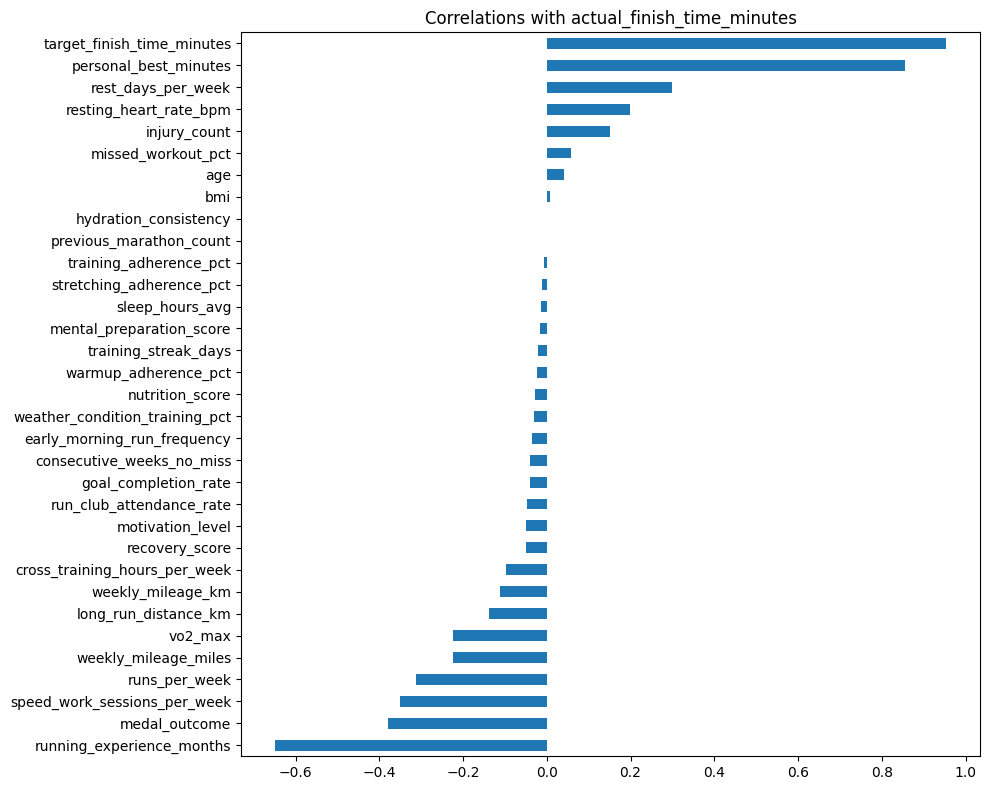

In [49]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr = df_train[numeric_cols].corr()['actual_finish_time_minutes'].sort_values()

plt.figure(figsize=(10, 8))
corr.drop('actual_finish_time_minutes').plot(kind='barh')
plt.title('Correlations with actual_finish_time_minutes')
plt.tight_layout()
plt.show()

In [52]:
df_train['personal_best_minutes'].head(10)

0      NaN
1    196.0
2    211.0
3      NaN
4      NaN
5      NaN
6    262.0
7      NaN
8    206.0
9    295.0
Name: personal_best_minutes, dtype: float64

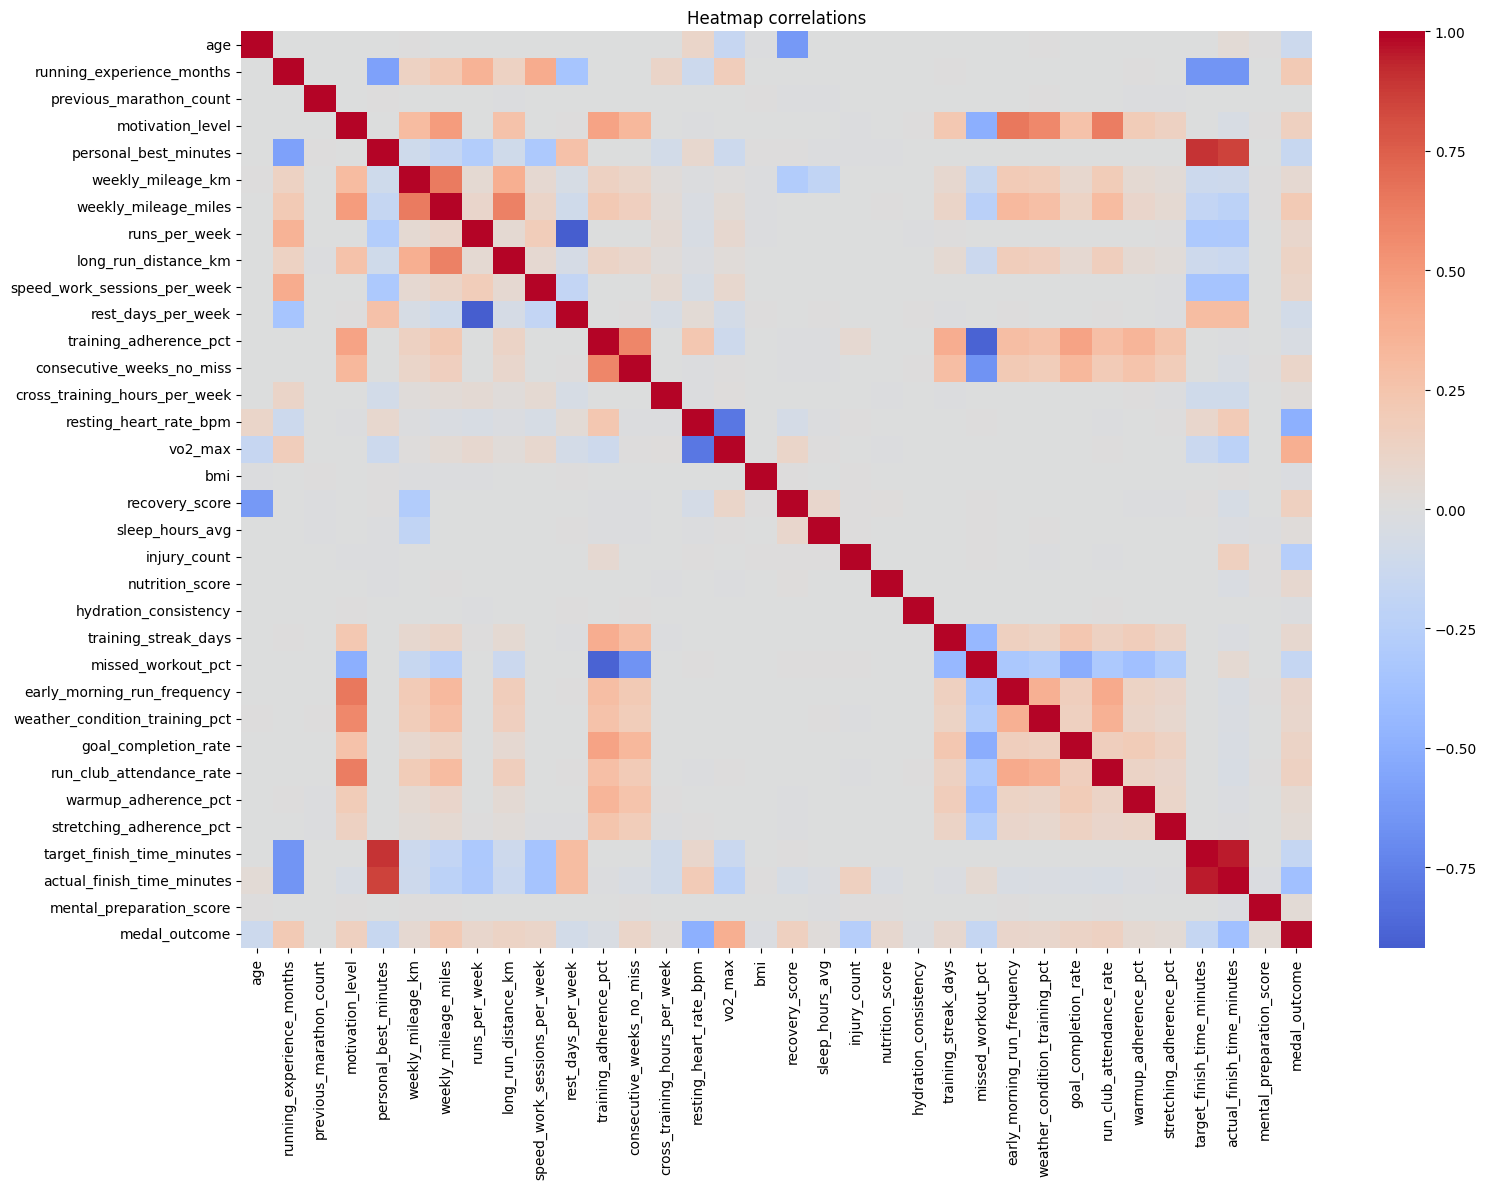

In [50]:
plt.figure(figsize=(16, 12))
sns.heatmap(df_train[numeric_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap correlations')
plt.tight_layout()
plt.show()

# Data Preparation

## Taking only 18-34 age group

In [54]:
df = df_train[df_train['age'].between(18, 34)]
df.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
6,R017407,18,Female,19,2,Beginner,1,262.0,20.0,12.4,...,0,43,29,2024-07-26,Sunny,Hilly,272,313.0,5,0
9,R086631,28,Female,38,4,Intermediate,7,295.0,45.0,28.0,...,33,74,78,2024-08-11,Cloudy,Flat,265,286.0,7,3
14,R083558,21,Male,96,0,Advanced,6,NaN,39.2,24.4,...,51,52,57,2025-10-08,Windy,Mixed,199,221.0,8,3


In [55]:
max(df['age'])

34

In [56]:
min(df['age'])

18

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28264 entries, 0 to 79998
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       28264 non-null  object 
 1   age                             28264 non-null  int64  
 2   gender                          28264 non-null  object 
 3   running_experience_months       28264 non-null  int64  
 4   previous_marathon_count         28264 non-null  int64  
 5   training_program                28264 non-null  object 
 6   motivation_level                28264 non-null  int64  
 7   personal_best_minutes           24454 non-null  float64
 8   weekly_mileage_km               28264 non-null  float64
 9   weekly_mileage_miles            28264 non-null  float64
 10  runs_per_week                   28264 non-null  int64  
 11  long_run_distance_km            28264 non-null  float64
 12  speed_work_sessions_per_week    28264

In [62]:
missing_df = df.isnull().sum()
print(missing_df[missing_df > 0])

personal_best_minutes             3810
cross_training_hours_per_week     2785
vo2_max                           3456
sleep_hours_avg                   1368
injury_severity                  16765
nutrition_score                   2199
hydration_consistency             2226
actual_finish_time_minutes         569
dtype: int64


In [63]:
df.shape

(28264, 41)

In [67]:
df.duplicated().sum()

0

In [65]:
df.shape

(28264, 41)

In [70]:
df.isnull().sum()[df.isnull().sum() > 0]

personal_best_minutes             3810
cross_training_hours_per_week     2785
vo2_max                           3456
sleep_hours_avg                   1368
injury_severity                  16765
nutrition_score                   2199
hydration_consistency             2226
actual_finish_time_minutes         569
dtype: int64

In [72]:
(df.isna().sum() / len(df) * 100)[df.isna().sum() > 0].round(2)

personal_best_minutes            13.48
cross_training_hours_per_week     9.85
vo2_max                          12.23
sleep_hours_avg                   4.84
injury_severity                  59.32
nutrition_score                   7.78
hydration_consistency             7.88
actual_finish_time_minutes        2.01
dtype: float64

In [88]:
df['actual_finish_time_minutes'].isnull().sum()/len(df)

0.020131616190206623

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28264 entries, 0 to 79998
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       28264 non-null  object 
 1   age                             28264 non-null  int64  
 2   gender                          28264 non-null  object 
 3   running_experience_months       28264 non-null  int64  
 4   previous_marathon_count         28264 non-null  int64  
 5   training_program                28264 non-null  object 
 6   motivation_level                28264 non-null  int64  
 7   personal_best_minutes           24454 non-null  float64
 8   weekly_mileage_km               28264 non-null  float64
 9   weekly_mileage_miles            28264 non-null  float64
 10  runs_per_week                   28264 non-null  int64  
 11  long_run_distance_km            28264 non-null  float64
 12  speed_work_sessions_per_week    28264

In [79]:
df['hydration_consistency'].unique()

array([ 7.,  5.,  3.,  8., 10.,  2.,  9., nan,  6.,  4.,  1.])

In [2]:
!git checkout -b corentin-branch

fatal: a branch named 'corentin-branch' already exists


In [3]:
!git status

On branch corentin-branch
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Corentin-data-exploration.ipynb
	requirements.txt
	requirements_dev.txt
	setup.py

nothing added to commit but untracked files present (use "git add" to track)
